---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** __장다예__ &nbsp; **학번:** ____20251281____ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. cancer.xlsx의 Data 시트 불러오기
df = pd.read_excel('cancer.xlsx', sheet_name='Data')
df.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
2,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Top dose,15,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
3,cancer_3383,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Rat,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026


In [2]:
# 데이터 내 존재하는 종(Species)의 분포 확인
df['Species'].value_counts()

Species
Mouse      3286
Rat        2905
Hamster      20
Name: count, dtype: int64

In [3]:
# Mouse 실험 결과+Chemical만 선택
df_m = df[(df['Species'] == 'Mouse') & (df['Mixture'] == 'Chemical')].copy()
df_m.head()

,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,Species,...,Endpoint,Response,Response_Unit,Reference,URL,SMILES,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS
0,cancer_4298,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Weakly Positive,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
1,cancer_4297,In Vivo,NaN,"Valeriana officinalis L., root extract","Valeriana officinalis L., root extract",8057-49-6,DTXSID001017359,NaN,Chemical,Mouse,...,Micronucleus,Negative,Unitless,NaN,https://cebs.niehs.nih.gov/cebs/test_article/8...,NaN,"Valeriana officinalis L., root extract","8057-49-6|Valeriana officinalis L., root extra...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID001017359
4,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
5,cancer_3382,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Level of evidence of carcinogenic activity,Inadequate experiment,Unitless,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026
6,cancer_3381,In Vivo,NaN,Acronycine,Acronycine,7008-42-6,DTXSID0020026,NaN,Chemical,Mouse,...,Top dose,25,mg/kg/day,TR-049,https://ntp.niehs.nih.gov/publications/reports...,COC1=CC2=C(C=CC(C)(C)O2)C2=C1C(=O)C1=C(C=CC=C1...,Acronycine,"7008-42-6|Acronycine|3,12-Dihydro-6-methoxy-3,...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID0020026


In [4]:
# 마우스 데이터 내에 존재하는 Endpoint 종류 및 빈도 확인
df_m['Endpoint'].value_counts()

Endpoint
Top dose                                      1100
Level of evidence of carcinogenic activity    1098
Micronucleus                                   612
POLY-3 lowest dose                             321
Comet assay                                     25
Name: count, dtype: int64

In [5]:
#'Level of evidence of carcinogenic activity(발암성 평가 결과)'를 가진 데이터 추출
df_evi = df_m[df_m['Endpoint'] == 'Level of evidence of carcinogenic activity'].copy()

# 불확실한 결과(Equivocal, Inadequate, Not tested 등) 제거
valid_responses = ['Clear evidence', 'Some evidence', 'No evidence']
df_evi = df_evi[df_evi['Response'].isin(valid_responses)].copy()
df_evi.shape

(897, 28)

In [6]:
# 필터링된 최종 발암성 응답 값들의 분포 확인
df_evi['Response'].value_counts()

Response
No evidence       516
Clear evidence    320
Some evidence      61
Name: count, dtype: int64

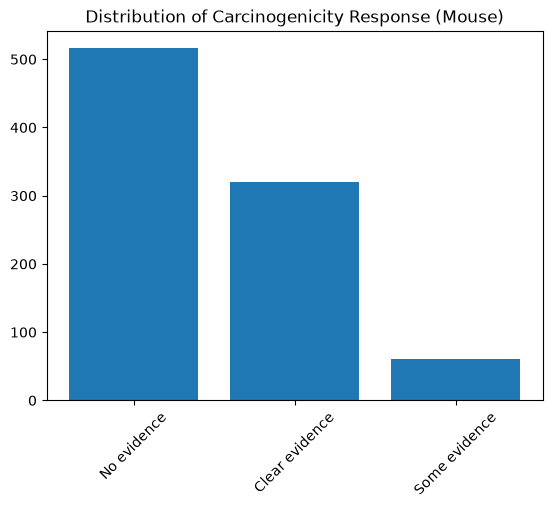

In [7]:
# 응답(Response) 값 분포 시각화
import matplotlib.pyplot as plt
evi_value = df_evi['Response'].value_counts()
plt.bar(evi_value.index, evi_value)
plt.xticks(rotation=45)
plt.title('Distribution of Carcinogenicity Response (Mouse)')
plt.show()

In [8]:
# 데이터 칼럼 확인
df_evi.columns

Index(['Record_ID', 'Data_Type', 'Formulation_ID', 'Formulation_Name',
       'Chemical_Name', 'CASRN', 'DTXSID', 'Percent_Active_Ingredient',
       'Mixture', 'Species', 'Sex', 'Strain', 'Route', 'Level_of_Evidence',
       'Tissue', 'Location', 'Lesion', 'Assay', 'Endpoint', 'Response',
       'Response_Unit', 'Reference', 'URL', 'SMILES', 'Preferred_Name',
       'Synonyms', 'URL_CompTox', 'URL_CEBS'],
      dtype='str')

In [9]:
# 타겟 변수 이진 라벨링 ('Clear evidence', 'Some evidence'(발암성 있음) = 1, 'No evidence'(발암성 없음) = 0)
df_evi['label'] = 0
df_evi.loc[df_evi['Response'].isin(['Clear evidence', 'Some evidence']),'label'] = 1

df_evi['label'].value_counts()

label
0    516
1    381
Name: count, dtype: int64

In [10]:
label_count = df_evi.groupby('SMILES')['label'].nunique()
label_count.head()

SMILES
*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|                        1
BrC(Br)Br                                                      1
BrC(Br)C#N                                                     1
BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2Br)C(Br)=C1Br    1
BrCC(Br)(CCC#N)C#N                                             1
Name: label, dtype: int64

In [11]:
len(label_count[label_count > 1])

51

In [12]:
conflict_smiles = label_count[label_count > 1].index
df_conflict = df_evi[df_evi['SMILES'].isin(conflict_smiles)]
df_conflict.shape

(113, 29)

In [13]:
df_conflict[['SMILES','Sex','label']].head(20)

,SMILES,Sex,label
24,CC(=O)OCC1=CC=CC=C1,Male,1
27,CC(=O)OCC1=CC=CC=C1,Female,1
33,CC(=O)OCC1=CC=CC=C1,Female,0
37,CC(=O)OCC1=CC=CC=C1,Male,0
57,NC1=CC(N)=C(Cl)C=C1,Male,0
61,NC1=CC(N)=C(Cl)C=C1,Female,1
529,CCCCC(CC)COP(=O)(OCC(CC)CCCC)OCC(CC)CCCC,Female,1
531,CCCCC(CC)COP(=O)(OCC(CC)CCCC)OCC(CC)CCCC,Male,0
687,"C*.O=C=NC1=CC(=CC=C1)N=C=O |c:6,8,t:4,lp:2:2,4...",Female,1
689,"C*.O=C=NC1=CC(=CC=C1)N=C=O |c:6,8,t:4,lp:2:2,4...",Male,0


In [14]:
smiles = 'CC(=O)OCC1=CC=CC=C1'

df_evi[df_evi['SMILES'] == smiles][['SMILES','Sex','Route','label']]

,SMILES,Sex,Route,label
24,CC(=O)OCC1=CC=CC=C1,Male,Gavage,1
27,CC(=O)OCC1=CC=CC=C1,Female,Gavage,1
33,CC(=O)OCC1=CC=CC=C1,Female,Dosed feed,0
37,CC(=O)OCC1=CC=CC=C1,Male,Dosed feed,0


In [15]:
# Route(투여 경로) 분포는 참고용으로 확인만 합니다.
# (이전 버전처럼 'Dosed feed'만 남기고 나머지를 버리지 않습니다 -> 데이터 손실 방지)
df_evi['Route'].value_counts()


Route
Dosed feed                   334
Gavage                       218
Inhalation                   109
Dermal                        39
Dosed drinking water          35
Intraperitoneal injection     11
Gavage; Dosed feed             4
Transplacental                 3
Dosed feed; Dermal             2
Intravaginal                   1
Name: count, dtype: int64

### 🔧 라벨 모순(conflicting label) 해결 방법

같은 화합물(SMILES)이 성별/투여경로 등에 따라 여러 행으로 기록되어 있어서,
화합물 1개에 라벨이 0과 1이 섞여 있는 경우(모순)가 51건 있었습니다.

이전 버전에서는 `Route == 'Dosed feed'`인 행만 남기는 방식으로 모순을 "회피"했는데,
이 경우 **분석 대상 화합물 수가 897건 → 334건으로 임의로 줄어드는 문제**가 있었고,
그 안에서도 여전히 23건은 모순이 남아 있어 결국 `drop_duplicates`로 그냥 먼저 나온
값을 채택해버리는 한계가 있었습니다.

대신 아래에서는 **화합물(SMILES) 단위로 모든 실험 결과를 모아 다수결(majority vote)**로
대표 라벨을 정합니다. 찬성/반대가 완전히 동률(예: 1:1)인 경우에만 "진짜 모순"으로 보고
해당 화합물을 제외합니다. 이렇게 하면 불필요한 데이터 손실 없이 더 많은 화합물을 보존할 수 있습니다.


In [33]:
# 화합물(SMILES) 단위로 라벨을 다수결(majority vote)로 통합합니다.
# - 라벨 값이 하나뿐이면 그대로 사용
# - 라벨이 섞여 있으면 더 많이 나온 값을 대표 라벨로 사용
# - 완전히 동률(예: 1:1)이면 신뢰할 수 없는 라벨이므로 NaN 처리 후 제외

def resolve_label(labels):
    counts = labels.value_counts()
    if len(counts) == 1:
        return counts.index[0]
    if counts.iloc[0] == counts.iloc[1]:
        return np.nan  # 동률 -> 진짜 모순 화합물, 이후 제외
    return counts.index[0]

resolved_label = df_evi.groupby('SMILES')['label'].apply(resolve_label)

n_total = len(resolved_label)
n_tie = int(resolved_label.isna().sum())
print(f"전체 화합물(SMILES) 수: {n_total}")
print(f"동률이라 제외되는 화합물 수: {n_tie}")

resolved_label = resolved_label.dropna()


전체 화합물(SMILES) 수: 446
동률이라 제외되는 화합물 수: 49


In [17]:
# 화합물별 메타데이터(이름, CASRN 등)는 가장 먼저 등장한 기록을 대표값으로 사용하고,
# 라벨은 위에서 다수결로 계산한 값으로 교체합니다.
df_route = df_evi.drop_duplicates(subset='SMILES').set_index('SMILES')
df_route = df_route.loc[resolved_label.index].reset_index()
df_route['label'] = resolved_label.values

print(df_route.shape)
df_route['label'].value_counts()


(397, 29)


label
0.0    238
1.0    159
Name: count, dtype: int64

In [18]:
df_route.to_csv('cancer_route.csv', index=False)


<!-- FILE1_AUTO_START -->
# File 1: Beginner Version

This version uses simple code syntax so it is easier to explain. It prepares descriptors and fingerprints only. Machine learning models will be done in File 2.

## Rubric Check

- Input data: `cancer.xlsx` from NTP ICE, preprocessed into `df_route`
- Preprocessing: missing SMILES check, duplicate SMILES check, **compound-level majority-vote label resolution** (instead of arbitrarily filtering to one Route), RDKit molecule conversion, cleaned (canonical) SMILES
- Descriptors: MolWt, MolLogP, TPSA, RingCount, NumHDonors, NumHAcceptors, NumRotatableBonds, FractionCSP3, NumAromaticRings, HeavyAtomCount
- Fingerprint: Morgan fingerprint bits + MACCS keys (two different fingerprint types for diversity)
- Visualization: label distribution (bar + pie), descriptor histograms, descriptor correlation heatmap, MolWt vs MolLogP scatter plot, **boxplot comparing descriptors by label**
- Output file: `final_dataset_descriptors.csv`



In [19]:
# 0. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem


In [20]:
# 1. Copy the preprocessed cancer_data

# df_route was made in the earlier preprocessing part.
cancer_data = df_route.copy()

# Check the first rows.
print(cancer_data.shape)
cancer_data.head()


(397, 29)


,SMILES,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,...,Endpoint,Response,Response_Unit,Reference,URL,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label
0,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",cancer_6589,In Vivo,NaN,Divinylbenzene-HP,Divinylbenzene,1321-74-0,DTXSID2025216,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-534,https://ntp.niehs.nih.gov/publications/reports...,Divinylbenzene,"1321-74-0|Divinylbenzene|Benzene, diethenyl-|B...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID2025216,0.0
1,BrC(Br)Br,cancer_3704,In Vivo,NaN,Tribromomethane,Bromoform,75-25-2,DTXSID1021374,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-350,https://ntp.niehs.nih.gov/publications/reports...,Bromoform,75-25-2|Bromoform|4-01-00-00082|BRN 1731048|br...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID1021374,0.0
2,BrC(Br)C#N,cancer_1266,In Vivo,NaN,Dibromoacetonitrile,Dibromoacetonitrile,3252-43-5,DTXSID3024940,NaN,Chemical,...,Level of evidence of carcinogenic activity,Clear evidence,Unitless,TR-544,https://ntp.niehs.nih.gov/publications/reports...,Dibromoacetonitrile,3252-43-5|Dibromoacetonitrile|4-02-00-00533|Ac...,https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID3024940,1.0
3,BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,cancer_5863,In Vivo,NaN,Decabromodiphenyl Oxide,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",1163-19-5,DTXSID9020376,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-309,https://ntp.niehs.nih.gov/publications/reports...,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether","1163-19-5|2,2',3,3',4,4',5,5',6,6'-Decabromodi...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID9020376,0.0
4,BrCC(Br)(CCC#N)C#N,cancer_1410,In Vivo,NaN,"1,2-Dibromo-2,4-Dicyanobutane","1,2-Dibromo-2,4-dicyanobutane",35691-65-7,DTXSID3024944,NaN,Chemical,...,Level of evidence of carcinogenic activity,No evidence,Unitless,TR-555,https://ntp.niehs.nih.gov/publications/reports...,"1,2-Dibromo-2,4-dicyanobutane","35691-65-7|1,2-Dibromo-2,4-dicyanobutane|1-Bro...",https://comptox.epa.gov/dashboard/chemical/det...,https://doi.org/10.22427/NTP-DATA-DTXSID3024944,0.0


In [21]:
# 2. Check important columns

# These checks show whether the cancer_data is ready to use.
print("Number of rows:", len(cancer_data))
print("Missing SMILES:", cancer_data["SMILES"].isna().sum())
print("Missing labels:", cancer_data["label"].isna().sum())
print("Duplicate SMILES:", cancer_data["SMILES"].duplicated().sum())

print("Label counts")
print(cancer_data["label"].value_counts())


Number of rows: 397
Missing SMILES: 0
Missing labels: 0
Duplicate SMILES: 0
Label counts
label
0.0    238
1.0    159
Name: count, dtype: int64


In [22]:
cancer_data[cancer_data["SMILES"].isna()]


,SMILES,Record_ID,Data_Type,Formulation_ID,Formulation_Name,Chemical_Name,CASRN,DTXSID,Percent_Active_Ingredient,Mixture,...,Endpoint,Response,Response_Unit,Reference,URL,Preferred_Name,Synonyms,URL_CompTox,URL_CEBS,label


In [34]:
# 3. Remove missing SMILES & convert to RDKit molecule objects

# Remove rows without SMILES.
cancer_data = cancer_data[cancer_data["SMILES"].notna()].copy()

# RDKit cannot calculate descriptors directly from text SMILES,
# so we convert each SMILES string into a molecule object.
cancer_data["mol"] = cancer_data["SMILES"].apply(Chem.MolFromSmiles)

# Remove rows where conversion failed (invalid SMILES).
cancer_data = cancer_data[cancer_data["mol"].notna()].copy()

print("missing SMILES 제거 후 남은 화합물 수:", len(cancer_data))


missing SMILES 제거 후 남은 화합물 수: 397


In [35]:
# 4. Make cleaned (canonical) SMILES and remove duplicate compounds

# RDKit's canonical SMILES lets us detect compounds that were written
# with different SMILES strings but are actually the same molecule.
cancer_data["clean_smiles"] = cancer_data["mol"].apply(Chem.MolToSmiles)
cancer_data = cancer_data.drop_duplicates("clean_smiles")

print("최종 화합물 수:", len(cancer_data))
cancer_data[["Chemical_Name", "SMILES", "clean_smiles", "label"]].head()


최종 화합물 수: 397


,Chemical_Name,SMILES,clean_smiles,label
0,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",*C=C.C=Cc1ccccc1,0.0
1,Bromoform,BrC(Br)Br,BrC(Br)Br,0.0
2,Dibromoacetonitrile,BrC(Br)C#N,N#CC(Br)Br,1.0
3,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,0.0
4,"1,2-Dibromo-2,4-dicyanobutane",BrCC(Br)(CCC#N)C#N,N#CCCC(Br)(C#N)CBr,0.0


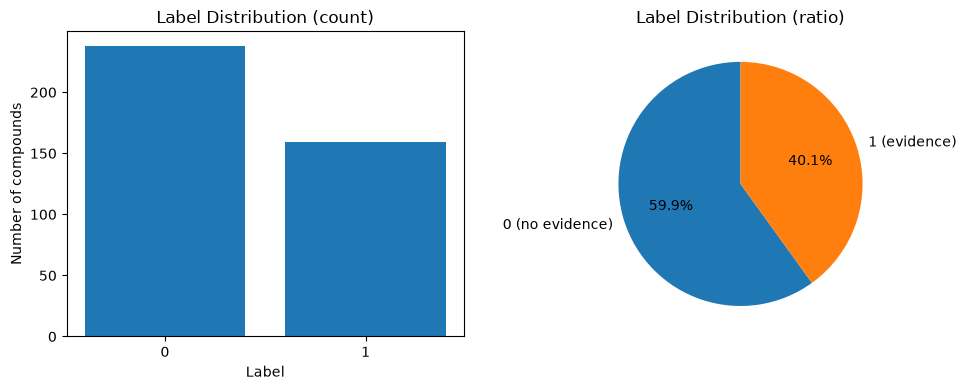

In [25]:
# 5. Draw label distribution (count + ratio)

# label 0 = no evidence
# label 1 = carcinogenic evidence

label_count = cancer_data["label"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["0", "1"], label_count)
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of compounds")
axes[0].set_title("Label Distribution (count)")

axes[1].pie(label_count, labels=["0 (no evidence)", "1 (evidence)"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Label Distribution (ratio)")

plt.tight_layout()
plt.show()


In [26]:
# 6. Calculate descriptors (more variety for richer features)

# MolWt          : molecular weight
# MolLogP        : hydrophobicity (octanol-water partition coefficient)
# TPSA           : topological polar surface area
# RingCount      : number of rings
# NumHDonors     : number of hydrogen bond donors
# NumHAcceptors  : number of hydrogen bond acceptors
# NumRotatableBonds : molecular flexibility
# FractionCSP3   : fraction of sp3 carbons (3D-ness / saturation)
# NumAromaticRings  : number of aromatic rings
# HeavyAtomCount : number of non-hydrogen atoms (rough size)

descriptor_funcs = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "RingCount": Descriptors.RingCount,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumAromaticRings": Descriptors.NumAromaticRings,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
}

descriptor_columns = list(descriptor_funcs.keys())

for name, func in descriptor_funcs.items():
    cancer_data[name] = cancer_data["mol"].apply(func)

cancer_data[descriptor_columns].head()


,MolWt,MolLogP,TPSA,RingCount,NumHDonors,NumHAcceptors,NumRotatableBonds,FractionCSP3,NumAromaticRings,HeavyAtomCount
0,131.198,3.00880,0.00,1,0,0,1,0.000000,1,10
1,252.731,2.45470,0.00,0,0,0,0,1.000000,0,4
2,198.845,1.62588,23.79,0,0,1,0,0.500000,0,5
3,959.171,11.10390,9.23,2,0,1,2,0.000000,2,23
4,265.936,2.34236,47.58,0,0,2,3,0.666667,0,10


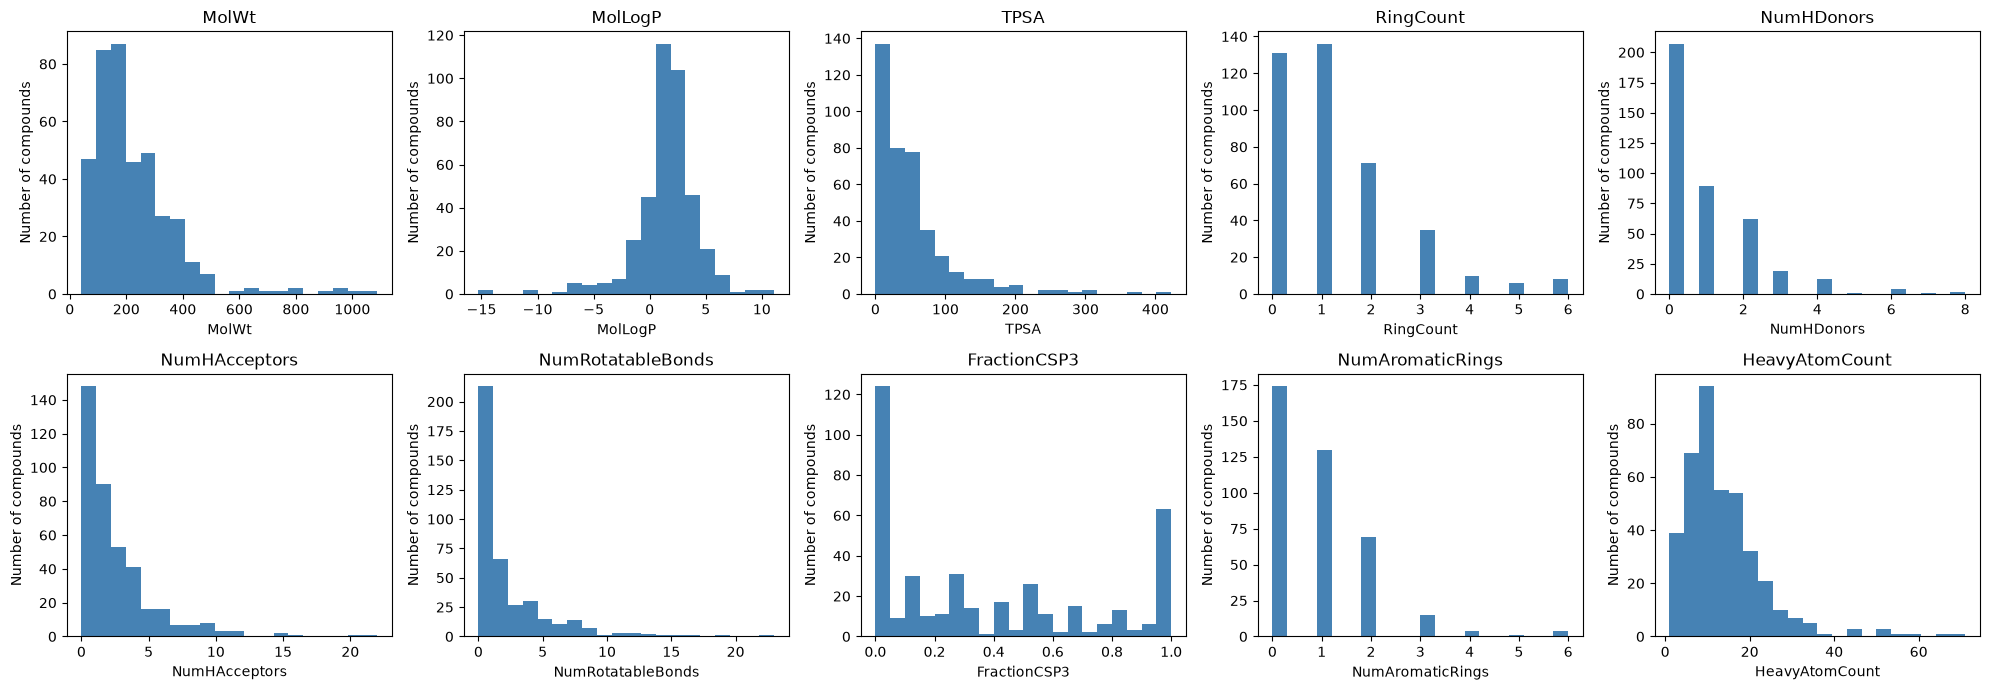

In [27]:
# 7. Draw descriptor histograms (loop over all descriptors)

n_cols = 5
n_rows = -(-len(descriptor_columns) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, descriptor_columns):
    ax.hist(cancer_data[col], bins=20, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Number of compounds")

# Hide unused subplots, if any.
for ax in axes[len(descriptor_columns):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


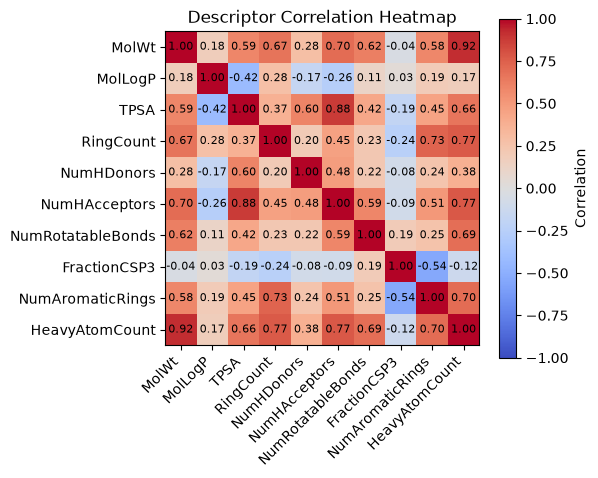

In [28]:
# 8. Descriptor correlation heatmap
# Shows whether descriptors carry redundant (highly correlated) or
# complementary (independent) information.

corr = cancer_data[descriptor_columns].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(descriptor_columns)))
ax.set_xticklabels(descriptor_columns, rotation=45, ha="right")
ax.set_yticks(range(len(descriptor_columns)))
ax.set_yticklabels(descriptor_columns)

for i in range(len(descriptor_columns)):
    for j in range(len(descriptor_columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Descriptor Correlation Heatmap")
plt.tight_layout()
plt.show()


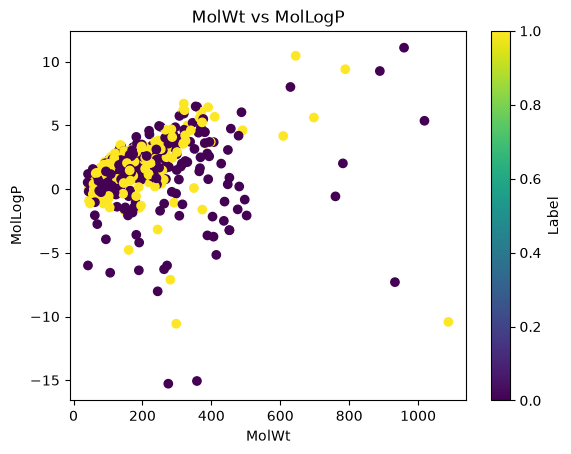

In [29]:
# 9. Draw a simple scatter plot

# This plot compares two descriptors.
# The color shows the label.

plt.scatter(cancer_data["MolWt"], cancer_data["MolLogP"], c=cancer_data["label"])
plt.xlabel("MolWt")
plt.ylabel("MolLogP")
plt.title("MolWt vs MolLogP")
plt.colorbar(label="Label")
plt.show()


In [30]:
# 10. Calculate Morgan fingerprints

# A fingerprint changes a molecule into numbers.
# Here we use 128 fingerprint bits.

fingerprint_list = []

for mol in cancer_data["mol"]:
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=128)
    arr = np.zeros((128,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fingerprint_list.append(arr)

fingerprint_data = pd.DataFrame(fingerprint_list)

print(fingerprint_data.shape)
fingerprint_data.head()


[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerator
[02:22:48] DEPRECATION WARNING: please use MorganGenerat

(397, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [31]:
# 11. Calculate MACCS keys (a second, different type of fingerprint)

# MACCS keys are a fixed set of 166 structural "yes/no" questions
# (e.g. "does the molecule contain a ring of size 6?").
# Using two different fingerprint types adds more variety of features.

from rdkit.Chem import MACCSkeys

maccs_list = []

for mol in cancer_data["mol"]:
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((167,), dtype=int)
    DataStructs.ConvertToNumpyArray(maccs_fp, arr)
    maccs_list.append(arr)

maccs_data = pd.DataFrame(maccs_list)

print(maccs_data.shape)
maccs_data.head()


(397, 167)


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,1,1,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


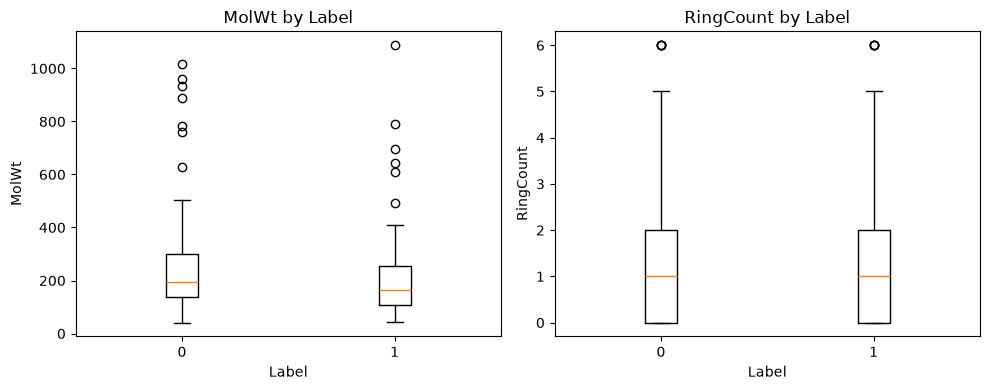

In [36]:
# 12. Compare descriptor distributions by label (boxplot)
# Instead of PCA, we use a simple boxplot to see whether carcinogenic (1)
# and non-carcinogenic (0) compounds tend to have different descriptor values.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

data_0 = cancer_data[cancer_data["label"] == 0]
data_1 = cancer_data[cancer_data["label"] == 1]

axes[0].boxplot([data_0["MolWt"], data_1["MolWt"]])
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["0", "1"])
axes[0].set_xlabel("Label")
axes[0].set_ylabel("MolWt")
axes[0].set_title("MolWt by Label")

axes[1].boxplot([data_0["RingCount"], data_1["RingCount"]])
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["0", "1"])
axes[1].set_xlabel("Label")
axes[1].set_ylabel("RingCount")
axes[1].set_title("RingCount by Label")

plt.tight_layout()
plt.show()

In [37]:
# 13. Add column names to fingerprints

# The Morgan fingerprint columns are named FP_0, FP_1, ... and the
# MACCS columns are named MACCS_0, MACCS_1, ...

fingerprint_data.columns = [f"FP_{i}" for i in range(fingerprint_data.shape[1])]
maccs_data.columns = [f"MACCS_{i}" for i in range(maccs_data.shape[1])]

fingerprint_data.head()


,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,FP_118,FP_119,FP_120,FP_121,FP_122,FP_123,FP_124,FP_125,FP_126,FP_127
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [38]:
# 14. Save final File 1 data

# This output file follows the assignment example and will be used for File 2 machine learning.

basic_columns = ["Chemical_Name", "SMILES", "clean_smiles", "label"]

basic_data = cancer_data[basic_columns].reset_index(drop=True)
descriptor_data = cancer_data[descriptor_columns].reset_index(drop=True)
fingerprint_data = fingerprint_data.reset_index(drop=True)
maccs_data = maccs_data.reset_index(drop=True)

cancer_final = pd.concat(
    [basic_data, descriptor_data, fingerprint_data, maccs_data], axis=1
)

cancer_final.to_csv("final_dataset_descriptors.csv", index=False)

print(cancer_final.shape)
cancer_final.head()


(397, 309)


,Chemical_Name,SMILES,clean_smiles,label,MolWt,MolLogP,TPSA,RingCount,NumHDonors,NumHAcceptors,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,Divinylbenzene,"*C=C.C=CC1=CC=CC=C1 |c:6,8,t:4,m:0:8.6|",*C=C.C=Cc1ccccc1,0.0,131.198,3.00880,0.00,1,0,0,...,0,0,0,0,0,1,1,0,1,1
1,Bromoform,BrC(Br)Br,BrC(Br)Br,0.0,252.731,2.45470,0.00,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Dibromoacetonitrile,BrC(Br)C#N,N#CC(Br)Br,1.0,198.845,1.62588,23.79,0,0,1,...,0,0,0,0,1,0,0,0,0,0
3,"2,2',3,3',4,4',5,5',6,6'-Decabromodiphenyl ether",BrC1=C(Br)C(Br)=C(OC2=C(Br)C(Br)=C(Br)C(Br)=C2...,Brc1c(Br)c(Br)c(Oc2c(Br)c(Br)c(Br)c(Br)c2Br)c(...,0.0,959.171,11.10390,9.23,2,0,1,...,1,0,0,0,0,1,1,1,1,0
4,"1,2-Dibromo-2,4-dicyanobutane",BrCC(Br)(CCC#N)C#N,N#CCCC(Br)(C#N)CBr,0.0,265.936,2.34236,47.58,0,0,2,...,0,0,0,0,1,0,0,0,0,0


<!-- FILE1_AUTO_END -->
